# Redes Neuronales Convolucionales


## ¿Qué es una CNN?

Una **Red Neuronal Convolucional (CNN)** es un tipo de red neuronal diseñada especialmente para procesar datos con estructura de grilla, como imágenes.

A diferencia de una red densa tradicional, las CNN aprenden **filtros** que detectan patrones locales (bordes, texturas, formas) en distintas capas de profundidad.

En este trabajo se implementa una CNN con Keras para **clasificar imágenes de 8 categorías de animales**:
Aves, Carpinchos, Elefantes, Gatos, Monos, Suricatas, Perros y Sapos.

---

## 0. Configuración del entorno

El dataset de imágenes está alojado en Google Drive. Para ejecutar este notebook:

1. Abrir el siguiente enlace y hacer clic en **'Agregar acceso directo a Mi unidad'**:  
    [Dataset Animales](https://drive.google.com/drive/folders/1MFSbP9Vh6-WUxOoWFsDZDMgxQJvHwINh?usp=drive_link)
2. Ejecutar la celda de abajo para montar tu Drive en Colab.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Preparación de los datos

Se divide el dataset en dos subconjuntos usando la utilidad de Keras:
- **80%** para entrenamiento
- **20%** para validación

Todas las imágenes se estandarizan a una resolución de **200×200 píxeles** para evitar errores de dimensión en la capa de entrada.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

directorio_datos = '/content/drive/MyDrive/Animales (1)'

TAMANO_IMAGEN = (200, 200)
TAMANO_LOTE = 32

datos_entrenamiento = tf.keras.utils.image_dataset_from_directory(
    directorio_datos,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE
)

datos_validacion = tf.keras.utils.image_dataset_from_directory(
    directorio_datos,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=TAMANO_IMAGEN,
    batch_size=TAMANO_LOTE
)

nombres_clases = datos_entrenamiento.class_names
print(f"Clases encontradas: {nombres_clases}")
print(f"Cantidad de clases: {len(nombres_clases)}")

Found 1567 files belonging to 8 classes.
Using 1254 files for training.
Found 1567 files belonging to 8 classes.
Using 313 files for validation.
Clases encontradas: ['Aves', 'Carpinchos', 'Elefantes', 'Gatos', 'Monos', 'Suricatas', 'perros', 'sapos']
Cantidad de clases: 8


## 2. Arquitectura del modelo (V1)

La arquitectura es una CNN secuencial con **cuatro bloques Conv2D + MaxPooling2D**.

Cada bloque extrae características cada vez más abstractas mientras reduce la resolución espacial:

| Bloque | Filtros | Salida |
|--------|---------|--------|
| 1 | 32 | 100×100×32 |
| 2 | 64 | 50×50×64 |
| 3 | 128 | 25×25×128 |
| 4 | 128 | 12×12×128 |

Finalmente, `Flatten` + dos capas densas actúan como clasificador, terminando en **8 neuronas con Softmax** (una por categoría).

In [3]:
modelo = keras.Sequential([
    layers.Input(shape=(200, 200, 3)),
    layers.Rescaling(1./255),

    # BLOQUE 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),   # Salida: 100x100x32

    # BLOQUE 2
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),   # Salida: 50x50x64

    # BLOQUE 3
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),   # Salida: 25x25x128

    # BLOQUE 4
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),   # Salida: 12x12x128

    # Clasificador (MLP)
    layers.Flatten(),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=8, activation='softmax')
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,288 (9.92 MB)

 Trainable params: 2,601,288 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento

Se compila con el optimizador **Adam** y la función de pérdida **sparse_categorical_crossentropy**.  
Se entrena por **15 épocas**.

In [4]:
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

NUMERO_DE_EPOCAS = 15

historia = modelo.fit(
    datos_entrenamiento,
    epochs=NUMERO_DE_EPOCAS,
    validation_data=datos_validacion
)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 258s 6s/step - accuracy: 0.1659 - loss: 2.0676 - val_accuracy: 0.2907 - val_loss: 1.8596
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.3397 - loss: 1.8040 - val_accuracy: 0.3866 - val_loss: 1.7635
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.4657 - loss: 1.5626 - val_accuracy: 0.4569 - val_loss: 1.5545
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.5351 - loss: 1.3202 - val_accuracy: 0.4888 - val_loss: 1.4743
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.6053 - loss: 1.1369 - val_accuracy: 0.5112 - val_loss: 1.3543
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.6643 - loss: 0.9496 - val_accuracy: 0.5559 - val_loss: 1.3097
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.7448 - loss: 0.7394 - val_accuracy: 0.5655 - val_loss: 1.4087
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.8477 - loss: 0.4797 - val_accuracy: 0.5655 - v

## 4. Análisis de resultados — Overfitting

Los resultados del entrenamiento revelan un problema claro de **overfitting**:

| Época | Acc. Entrenamiento | Loss Entrenamiento | Acc. Validación | Loss Validación |
|-------|-------------------|-------------------|-----------------|----------------|
| 12/15 | 0.9705 | 0.0986 | 0.5847 | 2.3412 |
| 13/15 | 0.9905 | 0.0482 | 0.5527 | 2.8006 |
| 14/15 | 0.9880 | 0.0391 | 0.5847 | 2.5845 |
| **15/15** | **0.9920** | **0.0321** | **0.5974** | **2.6283** |

La exactitud de entrenamiento alcanzó el **99%** mientras que la de validación se estancó en **~59%**.  
Esto indica que el modelo **memorizó** el dataset en lugar de aprender a generalizar.  
Además, la pérdida de validación aumenta progresivamente mientras la de entrenamiento cae, señal clásica de overfitting.

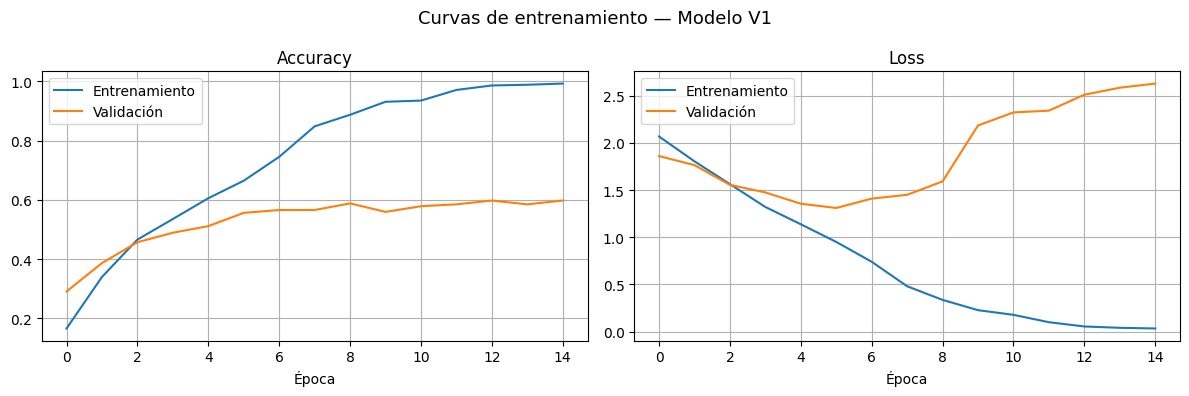

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historia.history['accuracy'], label='Entrenamiento')
ax1.plot(historia.history['val_accuracy'], label='Validación')
ax1.set_title('Accuracy')
ax1.set_xlabel('Época')
ax1.legend()
ax1.grid(True)

ax2.plot(historia.history['loss'], label='Entrenamiento')
ax2.plot(historia.history['val_loss'], label='Validación')
ax2.set_title('Loss')
ax2.set_xlabel('Época')
ax2.legend()
ax2.grid(True)

plt.suptitle('Curvas de entrenamiento — Modelo V1', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Prueba de predicción

Se prueba el modelo con una imagen de **Tom** (de Tom y Jerry) para observar su comportamiento real.  
La imagen está incluida en el dataset compartido.

La salida es un **vector softmax** con la probabilidad asignada a cada categoría.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Vector de Softmax (Probabilidades):
  Aves: 0.7027
  Carpinchos: 0.0000
  Elefantes: 0.0000
  Gatos: 0.0000
  Monos: 0.0014
  Suricatas: 0.0000
  perros: 0.0000
  sapos: 0.2959

Predicción de la Red: Aves
Confianza: 70.27%


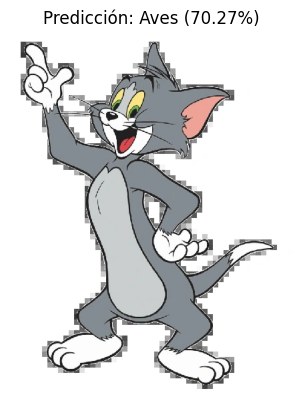

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.image import resize

ruta_imagen_prueba = '/content/drive/MyDrive/Animales (1)/Tom_Cat.webp'

img = load_img(ruta_imagen_prueba)
img_array = img_to_array(img)
img_resized = resize(img_array, [200, 200])
img_batch = np.expand_dims(img_resized, axis=0)

predicciones = modelo.predict(img_batch)
indice_predicho = np.argmax(predicciones[0])
nombre_predicho = nombres_clases[indice_predicho]
confianza = 100 * np.max(predicciones[0])

print("Vector de Softmax (Probabilidades):")
for nombre, prob in zip(nombres_clases, predicciones[0]):
    print(f"  {nombre}: {prob:.4f}")

print(f"\nPredicción de la Red: {nombre_predicho}")
print(f"Confianza: {confianza:.2f}%")

plt.figure()
plt.imshow(img)
plt.title(f"Predicción: {nombre_predicho} ({confianza:.2f}%)")
plt.axis('off')
plt.show()

## 6. Arquitectura modificada: Filtros Constantes (V2)

Para intentar reducir el overfitting, se implementó una segunda versión manteniendo **32 filtros fijos** en todos los bloques convolucionales.

Esto reduce drásticamente la cantidad de parámetros:
- **V1:** ~2.6M parámetros
- **V2:** ~619K parámetros (reducción del 75%)

La hipótesis es que un modelo más simple tendría menos capacidad para memorizar y mejor capacidad para generalizar.

In [7]:
modelo_v2 = keras.Sequential([
    layers.Input(shape=(200, 200, 3)),
    layers.Rescaling(1./255),

    # BLOQUE 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # BLOQUE 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # BLOQUE 3
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # BLOQUE 4
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Clasificador (MLP)
    layers.Flatten(),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=8, activation='softmax')
])

modelo_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,624 (2.36 MB)

 Trainable params: 619,624 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
historia_v2 = modelo_v2.fit(
    datos_entrenamiento,
    epochs=15,
    validation_data=datos_validacion
)

Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.1922 - loss: 2.0455 - val_accuracy: 0.2748 - val_loss: 1.9009
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.3421 - loss: 1.7816 - val_accuracy: 0.3962 - val_loss: 1.6747
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.4657 - loss: 1.5209 - val_accuracy: 0.4601 - val_loss: 1.4650
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.5510 - loss: 1.3024 - val_accuracy: 0.4952 - val_loss: 1.4505
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.5885 - loss: 1.1170 - val_accuracy: 0.5304 - val_loss: 1.3765
Epoch 6/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6882 - loss: 0.8982 - val_accuracy: 0.5399 - val_loss: 1.3376
Epoch 7/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7432 - loss: 0.7232 - val_accuracy: 0.5527 - val_loss: 1.3678
Epoch 8/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7871 - loss: 0.6029 - val_accuracy: 0.5431 - val_loss:

## 7. Análisis Comparativo de Arquitecturas

Al comparar los resultados de ambos modelos:

1. **Memorización persistente:** V1 llegó a accuracy de entrenamiento 0.9920; V2 lo moderó levemente (0.9944), pero ambos memorizaron el dataset.

2. **Falla en la generalización:** La accuracy de validación es similar en ambos (~58%). Reducir la capacidad del modelo **no resolvió** el problema.

3. **Estabilidad de la pérdida:** V1 finalizó con un val loss de 2.63 y V2 con 2.57 — valores similares que confirman que la simplificación del modelo no resolvió el problema.

**Conclusión:** el cuello de botella no es la arquitectura sino el **dataset** — pocas imágenes y poca variedad. La solución real sería aplicar técnicas de data augmentation o usar transfer learning con un modelo preentrenado.

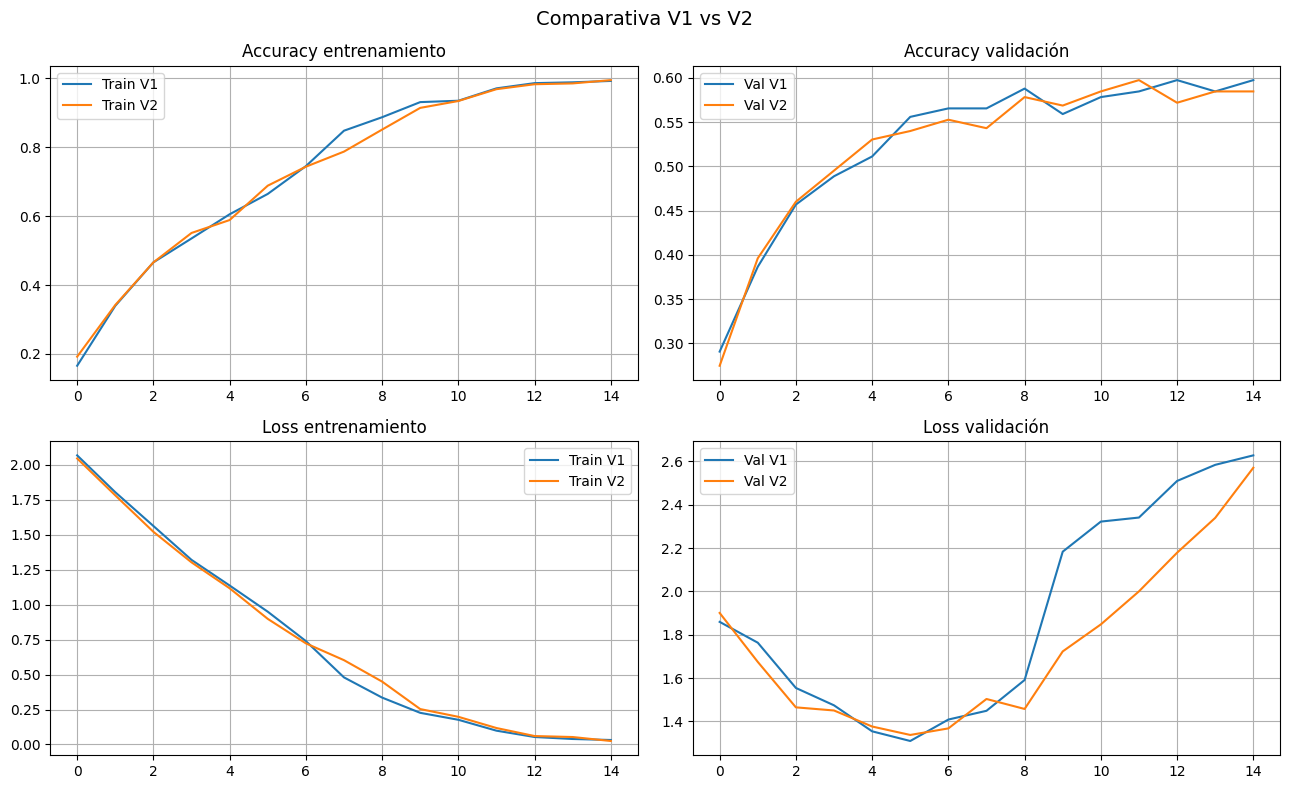

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(historia.history['accuracy'], label='Train V1')
axes[0, 0].plot(historia_v2.history['accuracy'], label='Train V2')
axes[0, 0].set_title('Accuracy entrenamiento')
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].plot(historia.history['val_accuracy'], label='Val V1')
axes[0, 1].plot(historia_v2.history['val_accuracy'], label='Val V2')
axes[0, 1].set_title('Accuracy validación')
axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].plot(historia.history['loss'], label='Train V1')
axes[1, 0].plot(historia_v2.history['loss'], label='Train V2')
axes[1, 0].set_title('Loss entrenamiento')
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].plot(historia.history['val_loss'], label='Val V1')
axes[1, 1].plot(historia_v2.history['val_loss'], label='Val V2')
axes[1, 1].set_title('Loss validación')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.suptitle('Comparativa V1 vs V2', fontsize=14)
plt.tight_layout()
plt.show()